         time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0  2024-10-01                30.0                12.9                 22.0   
1  2024-10-02                29.6                17.2                 22.5   
2  2024-10-03                27.6                12.8                 19.8   
3  2024-10-04                27.0                11.8                 18.3   
4  2024-10-05                27.9                10.8                 19.5   
5  2024-10-06                27.8                13.6                 20.4   
6  2024-10-07                29.2                11.6                 20.7   
7  2024-10-08                29.5                13.9                 21.8   
8  2024-10-09                28.5                14.6                 21.4   
9  2024-10-10                29.8                14.8                 21.9   
10 2024-10-11                28.0                14.4                 21.3   
11 2024-10-12                28.0                14.4           

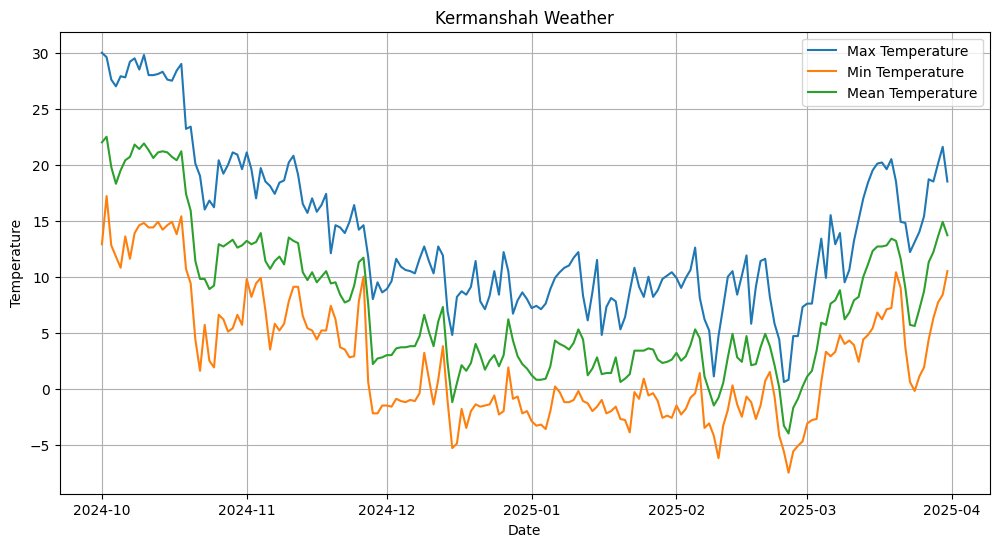

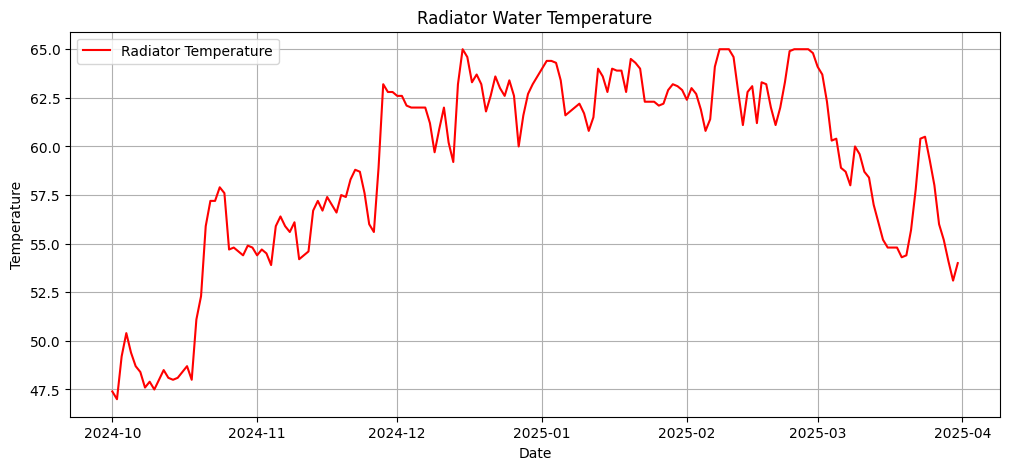


Risk Distribution:

risk
High    99
Low     83
Name: count, dtype: int64


In [9]:
# ============================================
# Smart Boiler Failure Prediction Project
# Version 3
# Weather Analysis + Thermal Simulation + Risk
# ============================================

import requests
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Download Weather Data
# --------------------------------------------

lat = 34.3142
lon = 47.0650

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2024-10-01",
    "end_date": "2025-03-31",
    "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)

data = response.json()

df = pd.DataFrame(data["daily"])

# --------------------------------------------
# 2. Prepare Data
# --------------------------------------------

df["time"] = pd.to_datetime(df["time"])

# --------------------------------------------
# 3. Warm-up Time
# --------------------------------------------

def calculate_warmup(temp):

    if temp > 15:
        return 8

    elif temp > 5:
        return 15

    elif temp > -5:
        return 25

    else:
        return 35

df["warmup_time"] = df["temperature_2m_mean"].apply(calculate_warmup)

# --------------------------------------------
# 4. Radiator Temperature Model
# --------------------------------------------

def calculate_radiator_temp(temp):

    radiator = 65 - (temp * 0.8)

    if radiator < 45:
        radiator = 45

    if radiator > 65:
        radiator = 65

    return round(radiator,1)

df["radiator_temp"] = df["temperature_2m_mean"].apply(calculate_radiator_temp)

# --------------------------------------------
# 5. Risk Label
# --------------------------------------------

def calculate_risk(row):

    if row["warmup_time"] >= 25 or row["radiator_temp"] >= 60:
        return "High"

    else:
        return "Low"

df["risk"] = df.apply(calculate_risk, axis=1)

# --------------------------------------------
# 6. Show Data
# --------------------------------------------

print(df.head(15))

print("\n")
print(df.info())

print("\n")
print(df.describe())

# --------------------------------------------
# 7. Save Dataset
# --------------------------------------------

df.to_csv("boiler_dataset.csv", index=False)

print("\nDataset Saved Successfully!")

# --------------------------------------------
# 8. Weather Chart
# --------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(df["time"],
         df["temperature_2m_max"],
         label="Max Temperature")

plt.plot(df["time"],
         df["temperature_2m_min"],
         label="Min Temperature")

plt.plot(df["time"],
         df["temperature_2m_mean"],
         label="Mean Temperature")

plt.title("Kermanshah Weather")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.grid()

plt.legend()

plt.show()

# --------------------------------------------
# 9. Radiator Temperature Chart
# --------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(df["time"],
         df["radiator_temp"],
         color="red",
         label="Radiator Temperature")

plt.title("Radiator Water Temperature")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.grid()

plt.legend()

plt.show()

# --------------------------------------------
# 10. Risk Count
# --------------------------------------------

print("\nRisk Distribution:\n")

print(df["risk"].value_counts())